# 02 · Signals and models

Phase 4 from `QUICKSTART.md`: how each feature relates to the next 30 s mid move, how
well the models predict it on validation, and which features they use. Run
`scripts/build_dataset.py` and `scripts/train.py` first.

Only **training and validation** rows are used here. Prediction metrics are secondary: the
backtest, by execution cost, decides which model and horizon are used.

In [1]:
import os
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from adaptive_exec.pipeline import load_config
from adaptive_exec.plotting import (AXIS, INK_2, SERIES, SURFACE, DIVERGING, apply_style,
                                    ci_dots, small_multiples, zero_line)

CONFIG = os.environ.get("ADAPTIVE_EXEC_CONFIG", "configs/stage1_itch.yaml")
cfg = load_config(CONFIG)
apply_style()
pd.set_option("display.width", 160, "display.max_columns", 30)
print(f"config: {CONFIG} | stage: {cfg['stage']} | symbols: {', '.join(cfg['symbols'])}")

config: configs/stage1_itch.yaml | stage: stage1_itch | symbols: AAPL, AMZN, GOOG, INTC, MSFT


In [2]:
from adaptive_exec.features import FEATURE_COLUMNS
from adaptive_exec.pipeline import main_kind, make_units, training_frames

units = [u for u in make_units(cfg) if u.kind == main_kind(cfg)]
frames = {}
for u in units:
    norms = json.loads((Path(cfg["models_dir"]) / u.name / "normalizers.json").read_text())
    train, val = training_frames(cfg, u, norms)
    frames[u.name] = (u, train, val)
{name: (len(tr), len(va)) for name, (_, tr, va) in frames.items()}

{'AAPL_2019-03-27': (9900, 4800),
 'AMZN_2019-03-27': (9900, 4800),
 'GOOG_2019-03-27': (9900, 4800),
 'INTC_2019-03-27': (9900, 4800),
 'MSFT_2019-03-27': (9900, 4800)}

## Rank correlation of each feature with the next 30 s move (training rows)

Spearman correlation per stock (unit). Blue = higher feature value goes with a falling mid, red = with a rising mid; gray = no relationship.

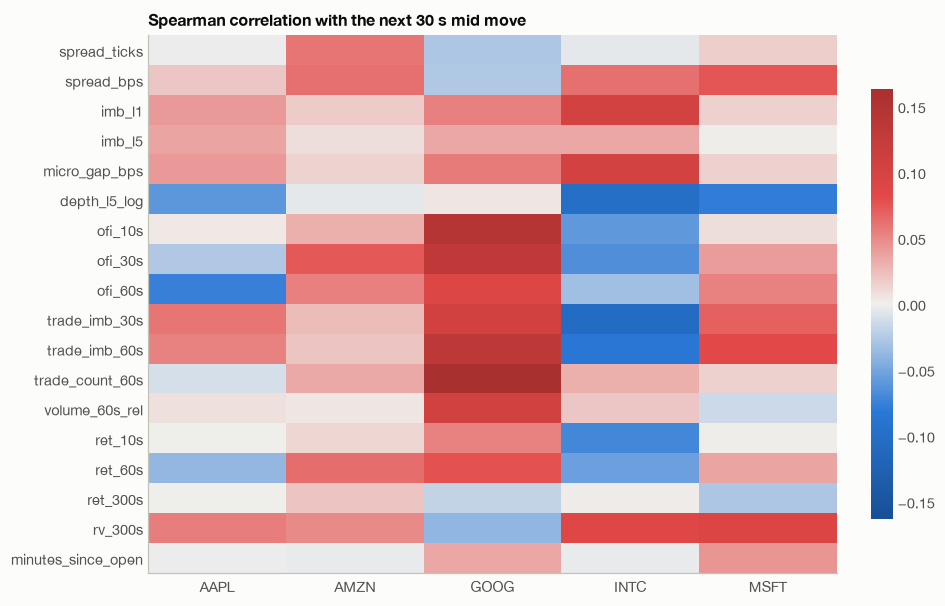

,AAPL_2019-03-27,AMZN_2019-03-27,GOOG_2019-03-27,INTC_2019-03-27,MSFT_2019-03-27
spread_ticks,-0.002,0.060,-0.027,-0.004,0.015
spread_bps,0.019,0.062,-0.026,0.062,0.075
imb_l1,0.041,0.017,0.055,0.104,0.015
imb_l5,0.036,0.008,0.035,0.035,0.000
micro_gap_bps,0.042,0.014,0.057,0.105,0.015
depth_l5_log,-0.060,-0.004,0.005,-0.098,-0.078
ofi_10s,0.003,0.032,0.143,-0.059,0.008
ofi_30s,-0.026,0.073,0.131,-0.066,0.040
ofi_60s,-0.076,0.054,0.090,-0.032,0.053
trade_imb_30s,0.059,0.024,0.105,-0.104,0.069


In [3]:
ic = pd.DataFrame({name: tr[FEATURE_COLUMNS].corrwith(tr["y_bps_30"], method="spearman")
                   for name, (_, tr, _) in frames.items()})
lim = float(np.nanmax(np.abs(ic.to_numpy()))) or 1.0
fig, ax = plt.subplots(figsize=(1.1 * ic.shape[1] + 3, 5.4), layout="constrained")
im = ax.imshow(ic.to_numpy(), cmap=DIVERGING, vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(ic.shape[1]), [c.split("_")[0] for c in ic.columns])
ax.set_yticks(range(ic.shape[0]), ic.index)
ax.grid(False)
ax.set_title("Spearman correlation with the next 30 s mid move")
cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.outline.set_visible(False)
plt.show()
ic.round(3)

## Validation accuracy by model and horizon

Correlation between prediction and outcome on the validation rows, for the 10, 30 and 60 s labels.

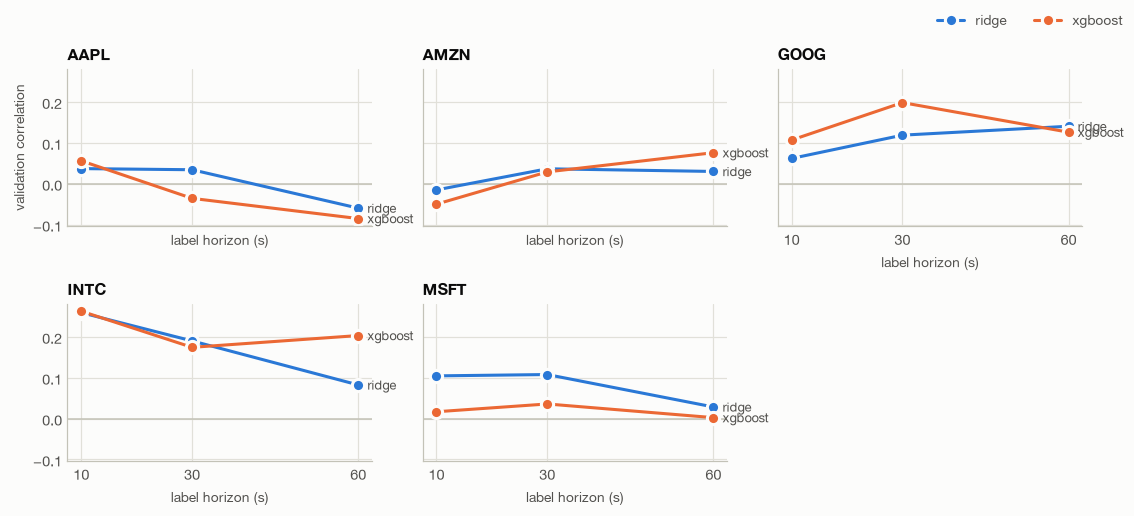

corr               hit_rate_nonzero                   r2              
horizon_s                   10     30     60               10     30     60     10     30     60
unit            model                                                                           
AAPL_2019-03-27 ridge    0.037  0.034 -0.060            0.492  0.499  0.477 -0.008 -0.026 -0.094
                xgboost  0.056 -0.036 -0.085            0.512  0.456  0.459  0.001 -0.006 -0.017
AMZN_2019-03-27 ridge   -0.015  0.036  0.030            0.498  0.466  0.486 -0.038 -0.089 -0.192
                xgboost -0.050  0.029  0.076            0.480  0.490  0.513 -0.006 -0.006 -0.024
GOOG_2019-03-27 ridge    0.062  0.119  0.141            0.546  0.548  0.534 -0.029 -0.062 -0.084
                xgboost  0.107  0.198  0.126            0.542  0.590  0.539  0.003  0.028  0.001
INTC_2019-03-27 ridge    0.259  0.190  0.082            0.621  0.545  0.502  0.018 -0.157 -0.530
                xgboost  0.263  0.174  0.203            0.639  0.564  0.554  0.067  0.029  0.032
MSFT_2019-03-27 ridge    0.104  0.108  0.028            0.534  0.527  0.494 -0.007 -0.055 -0.131
                xgboost  0.017  0.036  0.002            0.519  0.464  0.455 -0.014 -0.062 -0.112

In [4]:
pm = pd.read_csv(Path(cfg["results_dir"]) / "prediction_metrics.csv")
pm = pm[(pm["split"] == "validate") & (pm["kind"] == main_kind(cfg))]
fig, axes = small_multiples(pm["unit"].nunique(), ncols=3, sharex=True, sharey=True)
for ax, (unit_name, g) in zip(axes, pm.groupby("unit")):
    for color, (model, gm) in zip(SERIES, g.groupby("model")):
        gm = gm.sort_values("horizon_s")
        ax.plot(gm["horizon_s"], gm["corr"], "-o", color=color, label=model)
        ax.annotate(model, (gm["horizon_s"].iloc[-1], gm["corr"].iloc[-1]), xytext=(6, 0),
                    textcoords="offset points", va="center", color=INK_2, fontsize=8.5)
    zero_line(ax)
    ax.set_title(unit_name.split("_")[0])
    ax.set_xticks([10, 30, 60])
    ax.set_xlabel("label horizon (s)")
axes[0].set_ylabel("validation correlation")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside upper right", ncols=2)
plt.show()
pm.pivot_table(index=["unit", "model"], columns="horizon_s",
               values=["corr", "r2", "hit_rate_nonzero"]).round(3)

## Feature importance (XGBoost, 30 s label)

Share of total split gain, averaged over the per-stock models.

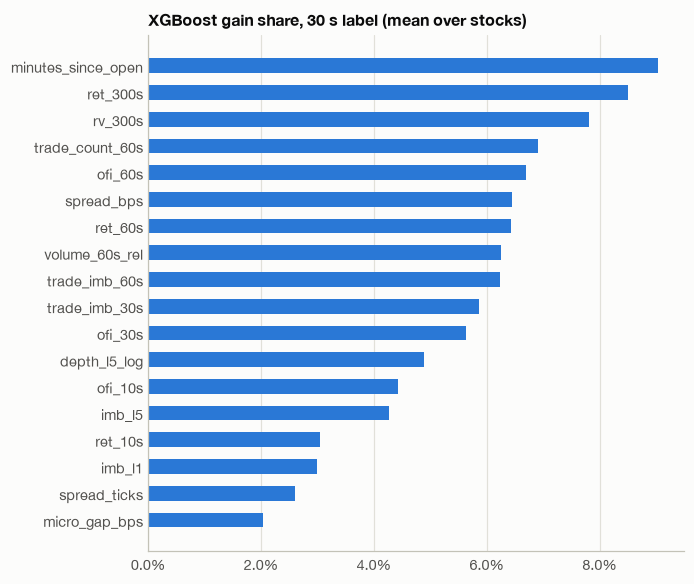

,gain share
feature,
minutes_since_open,9.0%
ret_300s,8.5%
rv_300s,7.8%
trade_count_60s,6.9%
ofi_60s,6.7%
spread_bps,6.4%
ret_60s,6.4%
volume_60s_rel,6.2%
trade_imb_60s,6.2%


In [5]:
fi = pd.read_csv(Path(cfg["results_dir"]) / "feature_importance.csv")
fi = fi[fi["kind"] == main_kind(cfg)]
imp = fi.groupby("feature")["xgboost_30s_gain_share"].mean().sort_values()
fig, ax = plt.subplots(figsize=(6.2, 5.2), layout="constrained")
ax.barh(imp.index, imp.to_numpy(), height=0.55, color=SERIES[0])
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.grid(axis="y", visible=False)
ax.set_title("XGBoost gain share, 30 s label (mean over stocks)")
plt.show()
imp.sort_values(ascending=False).map(lambda v: f"{v:.1%}").to_frame("gain share")

**What to expect:** out-of-sample R² for 30-second returns is usually a few percent or less,
and large-tick stocks often show no mid change at all within 30 s (see *share of zero moves*
in `results/<stage>/summary.md`). A weak signal applied thousands of times can still matter;
the backtest decides.